## CSCE 676 :: Data Mining and Analysis :: Texas A&M University :: Spring 2026


# Weekly Homework 7: Embeddings


***Goals of this homework:***
- Understand how word embedding models represent words as vectors.
- Compute and interpret cosine similarities between words.
- Visualize embeddings with PCA or t-SNE and assess whether the structure makes sense.
- Compare two embedding models and evaluate tradeoffs.
- Practice clear reasoning about assumptions, limitations, and evaluation of text representations.


***Submission instructions:***

You should post your notebook to Canvas (look for the assignment there). Please name your submission **your-uin_hw7.ipynb**. Your notebook should be fully executed when you submit ... so run all the cells for us so we can see the output, then submit that.

***Grading philosophy:***

We are grading reasoning, judgment, and clarity, not just correctness. Show us that you understand the data, the constraints, and the limits of your conclusions.

***For each question, you need to respond with 2 cells:***
1. **[A Code Cell] Your Code:**
  - If code is not applicable for the question, you can skip this cell.
  - For tests: tests can be simple assertions or checks (e.g., using `assert` or `print` or small functions or visual inspection); formal testing frameworks are not required.
2. **[A Markdown Cell] Your Answer:** Write up your answers and explain them in complete sentences. Include any videos in this section as well; for videos, upload them to your TAMU Google Drive, and ensure they are set to be visible by the instruction team (set to: **anyone with a TAMU email can view**), then share the link to the video in the cell.

***At the end of each Section (A/B/C/...) include a cell for your resources:***

**[A Markdown Cell] Your Resources:** You need to cite 3 types of resources and note how they helped you: (1) Collaborators, (2) Web Sources (e.g. StackOverflow), and (3) AI Tools (you must also describe how you prompted, but we do not require any links to any specific chats). Specifically, use the following format as a template:
```
On my honor, I declare the following resources:
1. Collaborators:
- Reveille A.: Helped me understand that a df in pandas is a data structure kinda like a CSV.
- Sully A.: Helped me fix a bug with the vector addition of 2 columns.
- ...

2. Web Sources:
- https://stackoverflow.com/questions/46562479/python-pandas-data-frame-creation: how to create a pd df
- ...

3. AI Tools:
- ChatGPT: I gave it the homework .ipynb file and the ufo.csv, and told it to generate the code for the first question, but it did it with csv.reader(), so I re-prompted it to use pandas and that one was correct
- ...
```
***Why do we require this cell?*** This cell is important...

1. For academic integrity, you must give credit where credit is due.

2. We want you to pay attention to how you can successfully get help to move through problems! Is there someone you work with or an AI tool that helps you learn the material better? That's great! The point of engineering is to use your tools to solve hard problems, and part of graduate school is learning about how *you* learn and solve problems best.

***A reminder: you get out of it what you put into it.***
Do your best on these homeworks, show us your creativity, and ask for help when you need it -- good luck!

# A [30pts].

**Rubric**

[10 pts] Strong/Professional: Correct and complete implementation of the task; Reasonable assumptions, stated or implied, and justified; Thoughtful handling of real-world data issues (missingness, noise, scale, duplicates, edge cases); Clear, concise explanations of what was done and why; Code is clean, readable, and well-structured, uses appropriate pandas, and would plausibly pass a professional code review; Tests meaningfully validate non-trivial behavior (not just "the code runs so it must be right").

[5 pts] Partial/Developing: Core task mostly completed but with gaps, weak assumptions, or minor mistakes; Reasoning is shallow or mostly descriptive; Code works but is messy, repetitive, or fragile; Tests are superficial, incomplete, or poorly motivated.

[0 pts] Minimal/Incorrect: Task is largely incorrect, missing, or misunderstands the goal; Little to no reasoning or justification; Code does not run or ignores constraints; No meaningful tests.


# 1. Embedding Model 1
- Find a contextual embedding model (search the web, use ChatGPT to help you, etc.), and obtain embeddings for the following words: **cat, dog, kitten, puppy, avocado, pear, car**
- Report cosine similarity between each possible pair of words in the list
- Reduce the dimensionality using PCA or t-SNE to 2, and plot each word
- What do you notice? Do you feel that the words are plotted correctly, or are some of the words in a spot that seems incorrect?

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Model used: sentence-transformers/all-MiniLM-L6-v2

Cosine similarity for each pair:
  word1   word2  cosine_similarity
    cat     dog             0.6606
    cat  kitten             0.7882
    cat   puppy             0.5329
    cat avocado             0.3073
    cat    pear             0.3683
    cat     car             0.4633
    dog  kitten             0.5205
    dog   puppy             0.8040
    dog avocado             0.2568
    dog    pear             0.3307
    dog     car             0.4756
 kitten   puppy             0.6146
 kitten avocado             0.3003
 kitten    pear             0.3030
 kitten     car             0.4350
  puppy avocado             0.3040
  puppy    pear             0.3224
  puppy     car             0.4644
avocado    pear             0.5160
avocado     car             0.3170
   pear     car             0.2957

Full cosine similarity matrix:
            cat     dog  kitten   puppy  avocado    pear     car
cat      1.0000  0.6606  0.7882  0.5329   0.307

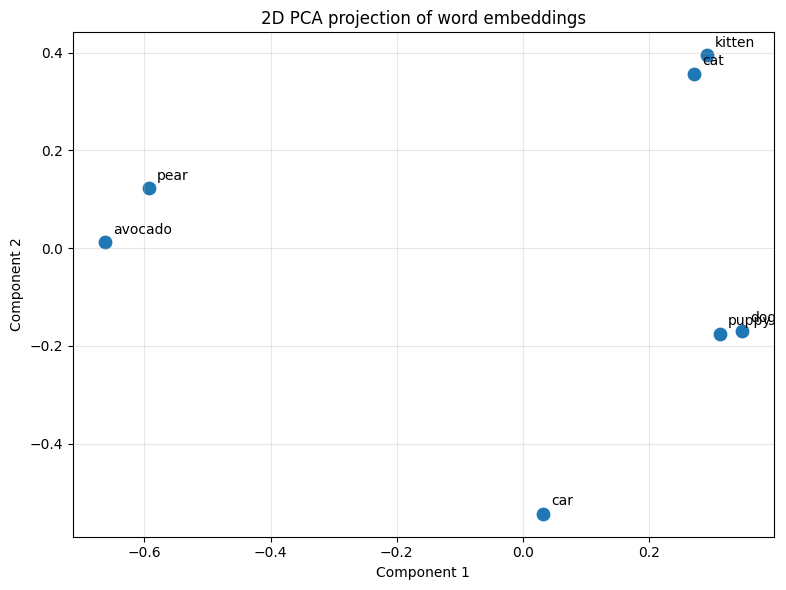


Nearest neighbor for each word:
cat      -> kitten   (cosine=0.7882)
dog      -> puppy    (cosine=0.8040)
kitten   -> cat      (cosine=0.7882)
puppy    -> dog      (cosine=0.8040)
avocado  -> pear     (cosine=0.5160)
pear     -> avocado  (cosine=0.5160)
car      -> dog      (cosine=0.4756)

Plot saved to: word_embeddings_pca.png


In [1]:
# pip install sentence-transformers scikit-learn matplotlib pandas

from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


def main():
    words = ["cat", "dog", "kitten", "puppy", "avocado", "pear", "car"]

    # A strong general-purpose embedding model
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
    model = SentenceTransformer(model_name)

    # Get embeddings
    embeddings = model.encode(words, convert_to_numpy=True, normalize_embeddings=False)

    # ------------------------------------------------------------
    # 1) Cosine similarity for each pair
    # ------------------------------------------------------------
    pair_rows = []
    similarity_matrix = np.zeros((len(words), len(words)))

    for i, w1 in enumerate(words):
        for j, w2 in enumerate(words):
            similarity_matrix[i, j] = cosine_similarity(embeddings[i], embeddings[j])

    for w1, w2 in combinations(words, 2):
        i = words.index(w1)
        j = words.index(w2)
        pair_rows.append(
            {
                "word1": w1,
                "word2": w2,
                "cosine_similarity": round(similarity_matrix[i, j], 4),
            }
        )

    pair_df = pd.DataFrame(pair_rows)
    matrix_df = pd.DataFrame(similarity_matrix, index=words, columns=words)

    print(f"\nModel used: {model_name}\n")

    print("Cosine similarity for each pair:")
    print(pair_df.to_string(index=False))

    print("\nFull cosine similarity matrix:")
    print(matrix_df.round(4).to_string())

    # ------------------------------------------------------------
    # 2) Dimensionality reduction to 2D
    #    Use PCA by default. You can switch to t-SNE below.
    # ------------------------------------------------------------
    use_tsne = False

    if use_tsne:
        reducer = TSNE(
            n_components=2,
            perplexity=min(5, len(words) - 1),
            random_state=42,
            init="random",
            learning_rate="auto",
        )
        reduced = reducer.fit_transform(embeddings)
        plot_title = "2D t-SNE projection of word embeddings"
        output_file = "word_embeddings_tsne.png"
    else:
        reducer = PCA(n_components=2, random_state=42)
        reduced = reducer.fit_transform(embeddings)
        plot_title = "2D PCA projection of word embeddings"
        output_file = "word_embeddings_pca.png"

    # ------------------------------------------------------------
    # 3) Plot words in 2D
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 6))
    plt.scatter(reduced[:, 0], reduced[:, 1], s=80)

    for i, word in enumerate(words):
        plt.annotate(
            word,
            (reduced[i, 0], reduced[i, 1]),
            textcoords="offset points",
            xytext=(6, 6),
        )

    plt.title(plot_title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_file, dpi=200)
    plt.show()

    # ------------------------------------------------------------
    # 4) Simple automatic observation helper
    # ------------------------------------------------------------
    print("\nNearest neighbor for each word:")
    for i, word in enumerate(words):
        sims = similarity_matrix[i].copy()
        sims[i] = -1.0  # ignore self-similarity
        nearest_idx = int(np.argmax(sims))
        print(f"{word:8s} -> {words[nearest_idx]:8s} (cosine={sims[nearest_idx]:.4f})")

    print(f"\nPlot saved to: {output_file}")

main()

For the most part, the distances between words in the graph make sense. Puppy and dog are close which makes sense since they are both related to dogs, cat and kitten are close which makes sense since both are related to cats, and avocado and pear are close which makes sense since both are related to food. It is interesting however that the cosine similarity of puppy and kitten isn't higher given that both are baby animals. The cosine similarity between kitten and puppy is .6146 and the cosine similarity of puppy and car is .41, which is not a huge gap.

# 2. Embedding Model 2
- Find a second contextual embedding model (search the web, use ChatGPT to help you, etc.), and obtain embeddings for the following words: **cat, dog, kitten, puppy, avocado, pear, car**
- Report cosine similarity between each possible pair of words in the list
- Reduce the dimensionality using t-SNE to 2, and plot each word
- What do you notice? Do you feel that the words are plotted correctly, or are some of the words in a spot that seems incorrect?

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


Cosine similarity between pairs:

      word1    word2  cosine_similarity
0       cat      dog           0.966521
1       cat   kitten           0.991605
2       cat    puppy           0.981814
3       cat  avocado           0.632367
4       cat     pear           0.982301
5       cat      car           0.959019
6       dog   kitten           0.949834
7       dog    puppy           0.964794
8       dog  avocado           0.701475
9       dog     pear           0.950552
10      dog      car           0.959863
11   kitten    puppy           0.976769
12   kitten  avocado           0.593026
13   kitten     pear           0.977469
14   kitten      car           0.952297
15    puppy  avocado           0.636595
16    puppy     pear           0.980100
17    puppy      car           0.952906
18  avocado     pear           0.635194
19  avocado      car           0.677037
20     pear      car           0.947433

Similarity matrix:

              cat       dog    kitten     puppy   avocado      p

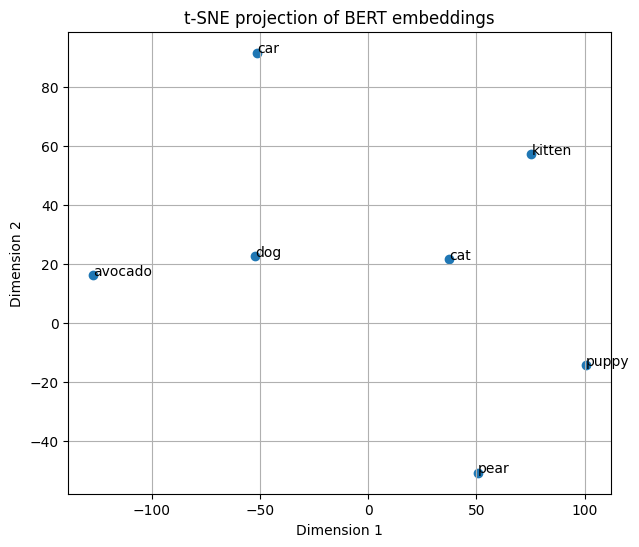

In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from itertools import combinations

words = ["cat","dog","kitten","puppy","avocado","pear","car"]

# Load BERT
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")

# Function to get embeddings
def get_embedding(word):
    inputs = tokenizer(word, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    # CLS token embedding
    embedding = outputs.last_hidden_state[:,0,:].squeeze().numpy()
    return embedding

# Generate embeddings
embeddings = np.array([get_embedding(w) for w in words])

# ----------------------------------------------------
# Cosine similarity
# ----------------------------------------------------

sim_matrix = cosine_similarity(embeddings)

pairs = []
for w1, w2 in combinations(range(len(words)),2):
    pairs.append({
        "word1": words[w1],
        "word2": words[w2],
        "cosine_similarity": sim_matrix[w1,w2]
    })

pair_df = pd.DataFrame(pairs)

print("\nCosine similarity between pairs:\n")
print(pair_df)

print("\nSimilarity matrix:\n")
print(pd.DataFrame(sim_matrix, index=words, columns=words))

# ----------------------------------------------------
# t-SNE reduction to 2D
# ----------------------------------------------------

tsne = TSNE(n_components=2, random_state=42, perplexity=3)
reduced = tsne.fit_transform(embeddings)

# ----------------------------------------------------
# Plot
# ----------------------------------------------------

plt.figure(figsize=(7,6))
plt.scatter(reduced[:,0], reduced[:,1])

for i, word in enumerate(words):
    plt.annotate(word,(reduced[i,0], reduced[i,1]))

plt.title("t-SNE projection of BERT embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)

plt.show()

Unlike the previous embedding, these embeddings don't make much sense from a spatial perspective. Puppy is closer to pear than it is to dog which doesn't make any sense from a semantical standpoint. This kind of makes sense if you are comparing words from a minimum edit distance perspective however.

# 3. Compare Embedding Model 1 and Embedding Model 2
- Compare the similarities/differences between the 2 models.
- Which model do you prefer? Why?

These models produced very different results. It seemed like miniLM was embedding words based on semantic meaning while Bert was using a more abstract method. It is much easier for me to understand the embeddigns produced by miniLM as opposed to Bert since miniLM grouped words like puppy and dog together, while Bert did not.  
I prefer the miniLM model because it seems to group words based on semantic meaning rather 

```
On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- None
3. AI Tools:
- ChatGPT 5.4: Just gave it the prompts for questions 1 and 2, and it wrote all of the code for me (one shot)
```

# B [60pts]. Interview Questions

We now pretend this is a real job interview. Here's some guidance on how to answer these questions:

1. Briefly restate the question and state any assumptions you are making.

2. Explain your reasoning out loud, focusing on tradeoffs, limitations, and constraints.

3. As a principle, keep your answers as short and clear as they can be (while still answering the question).

4. Write/speak in a conversational but professional tone (avoid being overly formal). For speaking: speak at a reasonable pace and volume, speak clearly, pause when you need to, and practice making "eye contact" with the camera. Keep a confident, positive, and professional tone. *For additional coaching and practice, the University Writing Center provides individual appointments: https://writingcenter.tamu.edu/make-an-appointment.*

There may not be a single correct answer. We are grading whether your reasoning is reasonable and aware of limitations.


**Rubric**

[10pt] Clear understanding of the question; reasonable assumptions; thoughtful reasoning that acknowledges tradeoffs and limitations; clear, concise communication in a conversational but professional tone (for speaking: clear pace, volume, and articulation).

[5pt] Basic understanding but shallow reasoning or unclear assumptions; communication is somewhat unclear, overly verbose, or overly informal/formal.

[0pt] Minimal, unclear, or incorrect response; poor communication or unprofessional tone.

# 1.
Isn't tokenization already solved? If modern LLMs use BPE, when does tokenization still materially affect model performance?

Tokenization is not solved, methods like BPE deteriorate when a language has many different forms for a word. For instance, Turkish has the word "ev" which means house, which has many forms including, "evlerimizden". This means BPE has to split “evlerimizden” into tokens such as “ev + ler + imiz + den,” or sometimes even smaller fragments if those combinations are rare in the training data. As a result, a single semantic unit (one word) becomes multiple tokens, increasing sequence length and fragmenting meaning across tokens, which can reduce efficiency and make it harder for the model to learn consistent representations.

# 2.
When would Cosine vs. Euclidean distance be more appropriate?

Cosine distance is usually better for word embeddings because it compares the direction of vectors, which reflects how similar two words are in meaning. Euclidean distance compares the actual distance between points, so it is affected by how large the vectors are. Since embedding magnitude often varies for reasons unrelated to meaning, cosine similarity usually gives more reliable semantic comparisons.

# 3.
How does word2vec handle rare words? Compare this to tf-idf embeddings.

Word2vec handles rare words poorly because they appear in very few contexts during training, so the model cannot learn reliable embeddings for them. TF-IDF does not have this issue because each word is represented directly by how often it appears in documents, so even rare words get a clear representation.

# 4.
Do embeddings capture meaning, or just statistical regularities?
Is there a difference in practice?

Embeddings mainly capture statistical patterns in how words appear together, not meaning in a human sense. However, these patterns often reflect real relationships between words, so the vectors behave as if they contain meaning. In practice, this difference usually doesn’t matter much because the statistical patterns are enough for models to perform useful language tasks.

# 5.
How should we evaluate a text representation (e.g. tf-idf or word2vec embeddings) independent of a downstream task?


You can evaluate a text representation by checking whether similar texts or words end up close together in the vector space. This is often done using intrinsic evaluations, such as word similarity benchmarks where the embedding’s similarity scores are compared with human judgments. You can also examine whether the representation captures useful structure through clustering or visualization of the embeddings.

# 6.
(Video) What is the “right” amount of dimensions for an embedding space?

https://drive.google.com/file/d/1miy1a7lUi-cj3srNTJQcO-_iPxCvOiFP/view?usp=drive_link

```
On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- None
3. AI Tools:
- ChatGPT 5.4: Helped guide me through these problems, I wasn't super familar with BPE and the specifics of word2vec and tf-idf
```

# C [10pts]. What new questions do you have?
We want you to think bigger! Tell us what questions and curiosity this homework brings up for you.

**Rubric**

[10pt] Complete, thoughtful response.

[5pt] Partial response.

[0pt] Minimal response.

# 1.
What new questions do you have after this homework? Or, what topics are you curious about now? List at least 3.

How do tokenization algorithms impact LLM performance?  
How to train embedding models on distributed systems?  
How to synchronize training in multi-node set ups?

```
On my honor, I declare the following resources:
1. Collaborators:
- None

2. Web Sources:
- None
3. AI Tools:
- None
```